# Neural Network Testing Notebook

### Loading Files

In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np
import random

from network import FCN, Layer
from metrics import confusion_matrix, accuracy, plot_losses, summary

### Essential Functions

In [12]:
def show_digit(X, y, index):
    plt.imshow(X[index].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y[index])}")
    plt.axis('off')
    plt.show()

In [13]:
def one_hot(y, classes=10):
    encoded = np.zeros((len(y), classes))
    encoded[np.arange(len(y)), y] = 1
    return encoded

### Main testing model

In [15]:
# initialize network with 2 hidden layers
network = FCN([
    Layer(784),
    Layer(128, 'leaky_relu', dropout=0.4),
    Layer(64, 'leaky_relu', dropout = 0.3),
    Layer(10, 'softmax')
],
learning_rate=0.01,
loss = "cross_entropy",
optimiser="adam")

# load mnist data and split into train and test partitions
(X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()
y_train_full = one_hot(y_train_full)
y_test = one_hot(y_test)

# flatten each image from (28x28) to 784, then normalise to [0,1]
X_train_full = X_train_full.reshape(60000, 784) / 255.0
X_test  = X_test.reshape(10000, 784)  / 255.0

X_train, y_train = X_train_full[:50000], y_train_full[:50000]
X_val, y_val = X_train_full[50000:], y_train_full[50000:]

FCN initialized


Epoch 1/50 - Loss: 0.0173
Model improved!
Validation Loss: 0.2089 - Validation Accuracy: 94.05%
...
Epoch 2/50 - Loss: 0.0131
Model improved!
Validation Loss: 0.2026 - Validation Accuracy: 94.06%
...
Epoch 3/50 - Loss: 0.0122
Validation Loss: 0.2041 - Validation Accuracy: 94.19%
...
Epoch 4/50 - Loss: 0.0117
Validation Loss: 0.2138 - Validation Accuracy: 93.90%
...
Epoch 5/50 - Loss: 0.0115
Model improved!
Validation Loss: 0.1836 - Validation Accuracy: 95.10%
...
Epoch 6/50 - Loss: 0.0108
Model improved!
Validation Loss: 0.1811 - Validation Accuracy: 95.34%
...
Epoch 7/50 - Loss: 0.0109
Validation Loss: 0.1816 - Validation Accuracy: 95.20%
...
Epoch 8/50 - Loss: 0.0104
Model improved!
Validation Loss: 0.1716 - Validation Accuracy: 95.51%
...
Epoch 9/50 - Loss: 0.0102
Validation Loss: 0.1766 - Validation Accuracy: 95.45%
...
Epoch 10/50 - Loss: 0.0100
Model improved!
Validation Loss: 0.1672 - Validation Accuracy: 95.81%
...
Epoch 11/50 - Loss: 0.0095
Validation Loss: 0.1853 - Validation

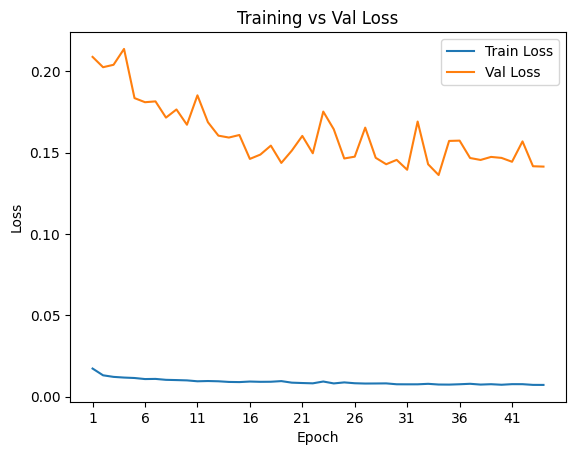

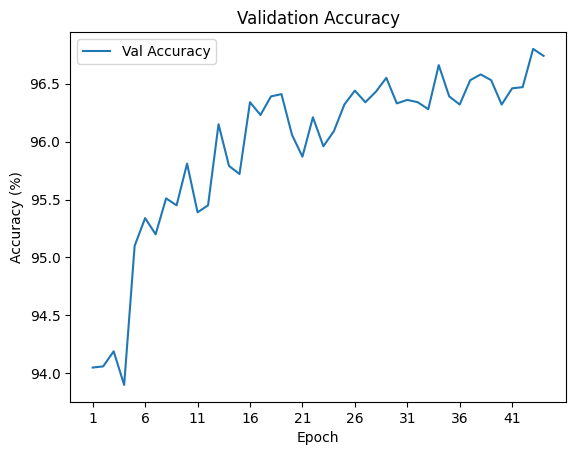

Test Accuracy: 96.17%


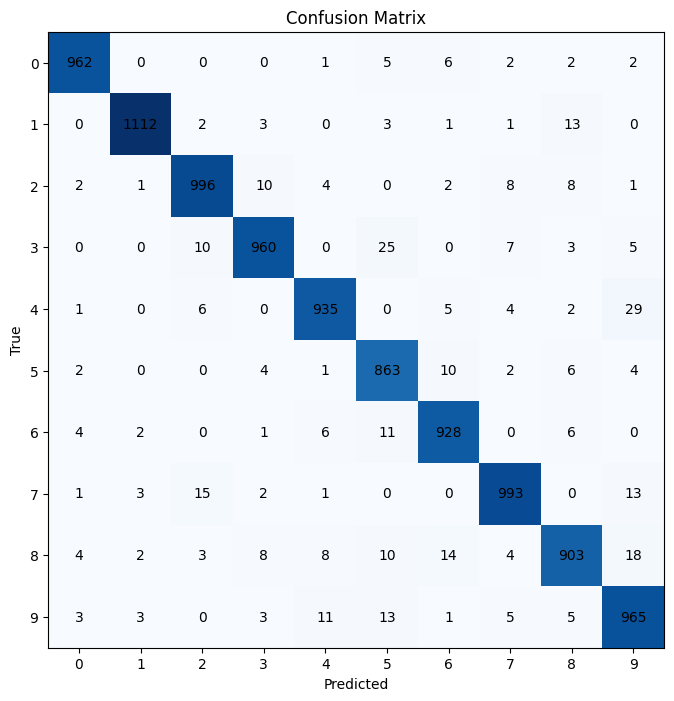

In [16]:
losses = network.train(X_train, y_train, X_val, y_val, epochs=50, batch_size=32, patience=10)

# display some metrics
plot_losses(losses)
summary(network, X_test, y_test)

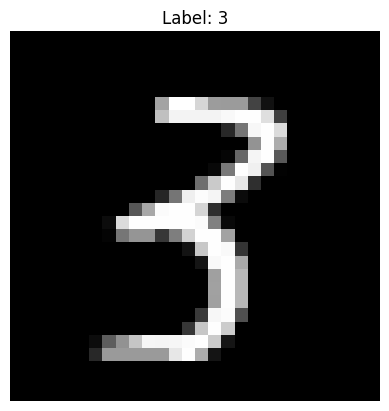

[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
Prediction: 3


In [17]:
index = random.randint(0, 9999)
show_digit(X_test, y_test, index)
np.set_printoptions(precision=4, suppress=True)
pred = network.predict(X_test[index])
print(pred)
print("Prediction:", np.argmax(pred))

#### Testing save and load functionality

In [18]:
network.save("model.npz")

FCN initialized
Model Loaded


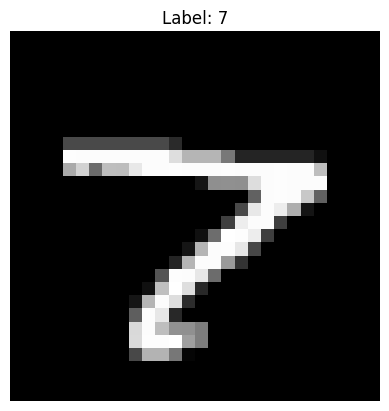

[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
Prediction: 7


In [19]:
network2 = FCN([
    Layer(784),
    Layer(128, 'leaky_relu'),
    Layer(64, 'leaky_relu'),
    Layer(10, 'softmax')
],
learning_rate=0.01,
loss = "cross_entropy",
optimiser="adam")

network2.load("model.npz")

index = random.randint(0, 9999)
show_digit(X_test, y_test, index)
np.set_printoptions(precision=4, suppress=True)
pred = network2.predict(X_test[index])
print(pred)
print("Prediction:", np.argmax(pred))


In [20]:
print("Testing incorrect number of layers:")
network2 = FCN([
    Layer(784),
    Layer(64, 'leaky_relu'),
    Layer(10, 'softmax')
],
learning_rate=0.01,
loss = "cross_entropy",
optimiser="adam")

network2.load("model.npz")

print("--------------------")

print("Testing incorrect number of neurons:")
network2 = FCN([
    Layer(784),
    Layer(64, 'leaky_relu'),
    Layer(64, 'leaky_relu'),
    Layer(10, 'softmax')
],
learning_rate=0.01,
loss = "cross_entropy",
optimiser="adam")

network2.load("model.npz")

print("---------------------")

print("Testing incorrect file name:")
network2.load("fake.npz")

Testing incorrect number of layers:
FCN initialized
Model architecture is not compatible with save file
--------------------
Testing incorrect number of neurons:
FCN initialized
Model architecture is not compatible with save file
---------------------
Testing incorrect file name:
Error finding file


### Testing Batch sizes vs Val Accuracy

FCN initialized
Epoch 1/5 - Loss: 0.2369
...
Epoch 2/5 - Loss: 0.1069
...
Epoch 3/5 - Loss: 0.0749
...
Epoch 4/5 - Loss: 0.0560
...
Epoch 2/5 - Loss: 0.0349
...
Epoch 3/5 - Loss: 0.0332
...
Epoch 4/5 - Loss: 0.0315
...
Epoch 5/5 - Loss: 0.0300
...
Batch size 64: 54.66%
FCN initialized
Epoch 1/5 - Loss: 0.0183
...
Epoch 2/5 - Loss: 0.0180
...
Epoch 3/5 - Loss: 0.0177
...
Epoch 4/5 - Loss: 0.0175
...
Epoch 5/5 - Loss: 0.0172
...
Batch size 128: 22.54%
FCN initialized
Epoch 1/5 - Loss: 0.0094
...
Epoch 2/5 - Loss: 0.0094
...
Epoch 3/5 - Loss: 0.0093
...
Epoch 4/5 - Loss: 0.0093
...
Epoch 5/5 - Loss: 0.0092
...
Batch size 256: 11.02%
Batch sizes: [1, 8, 32, 64, 128, 256]


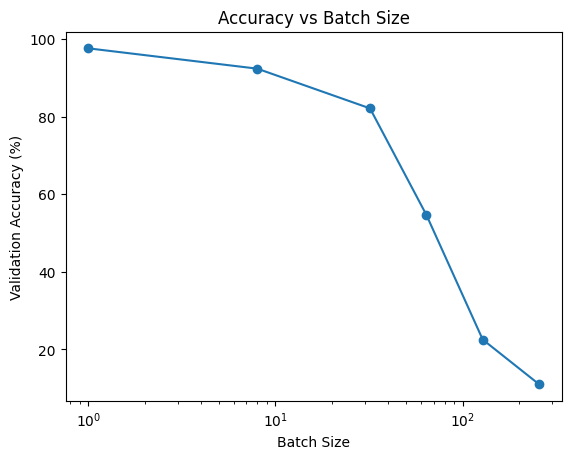

In [9]:
# testing batch_size
batch_sizes = [1, 8, 32, 64, 128, 256]
results = {}

for bs in batch_sizes:
    model = FCN([
        Layer(784),
        Layer(128, 'relu'),
        Layer(10, 'softmax')
    ], loss='cross_entropy', learning_rate=0.01)
    
    model.train(X_train, y_train, epochs=5, batch_size=bs)
    acc = accuracy(model, X_val, y_val)
    results[bs] = acc
    print(f"Batch size {bs}: {acc:.2f}%")

# plot
print("Batch sizes:", batch_sizes)
plt.plot(list(results.keys()), list(results.values()), marker='o')
plt.xscale('log')
plt.xlabel('Batch Size')
plt.ylabel('Validation Accuracy (%)')
plt.title('Accuracy vs Batch Size')
plt.show()

### Random testing

In [9]:
n = 10
rate = 0.4
mask = np.random.rand(n)
mask = mask > rate
print(mask)

[ True False  True  True False  True  True  True False False]
